In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\VP678WV\\OneDrive - EY\\Documents\\Delivery_Delay\\data\\raw\\mim2025_delay_sample.csv")
df.head()

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_region,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label
0,PAYMENT,101.010895,195.02570,46,Indoor/Outdoor Games,Milford,EE. UU.,3736.8790,Home Office,CT,...,Western Europe,Vienna,PENDING_PAYMENT,1014,46,O'Brien Men's Neoprene Life Vest,49.98,42322.746,Standard Class,0
1,TRANSFER,85.423610,245.20793,46,Indoor/Outdoor Games,Caguas,Puerto Rico,4268.8580,Consumer,PR,...,South America,Buenos Aires,PENDING,1014,46,O'Brien Men's Neoprene Life Vest,49.98,42340.965,Standard Class,1
2,PAYMENT,261.173770,456.55527,9,Cardio Equipment,Caguas,Puerto Rico,7772.3945,Consumer,PR,...,Western Europe,West Flanders,PENDING_PAYMENT,191,9,Nike Men's Free 5.0+ Running Shoe,99.99,42061.550,Standard Class,-1
3,DEBIT,-52.374670,191.65901,48,Water Sports,Caguas,Puerto Rico,9977.6810,Consumer,PR,...,South America,O'Higgins,COMPLETE,1073,48,Pelican Sunstream 100 Kayak,199.99,42883.145,Standard Class,-1
4,DEBIT,55.085342,187.45561,48,Water Sports,Caguas,Puerto Rico,8920.0180,Consumer,PR,...,East of USA,New York,ON_HOLD,1073,48,Pelican Sunstream 100 Kayak,199.99,42950.610,Standard Class,0


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, kruskal, chi2_contingency
import warnings

warnings.filterwarnings("ignore")  # Hide warnings for cleaner output

# Load your DataFrame here
# df = pd.read_csv('your_data.csv')

TARGET_COL = 'label'

# Step 1: Define columns to drop (IDs, datetime, and irrelevant free-text for now)
drop_cols = [
    'customer_id', 'order_id', 'order_item_id', 'order_customer_id',
    'order_item_cardprod_id', 'product_card_id', 'product_category_id',
    'category_id', 'order_date', 'shipping_date'
    # 'category_name', 'customer_zipcode', 'department_name', 'product_name'
]

# Step 2: Drop them
df_cleaned = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [5]:
df_cleaned

,payment_type,profit_per_order,sales_per_customer,category_name,customer_city,customer_country,customer_segment,customer_state,customer_zipcode,department_id,...,sales,order_item_total_amount,order_profit_per_order,order_region,order_state,order_status,product_name,product_price,shipping_mode,label
0,PAYMENT,101.010895,195.02570,Indoor/Outdoor Games,Milford,EE. UU.,Home Office,CT,63031.027,7,...,199.920000,193.922400,91.143528,Western Europe,Vienna,PENDING_PAYMENT,O'Brien Men's Neoprene Life Vest,49.980000,Standard Class,0
1,TRANSFER,85.423610,245.20793,Indoor/Outdoor Games,Caguas,Puerto Rico,Consumer,PR,725.000,7,...,249.900000,247.401000,81.642330,South America,Buenos Aires,PENDING,O'Brien Men's Neoprene Life Vest,49.980000,Standard Class,1
2,PAYMENT,261.173770,456.55527,Cardio Equipment,Caguas,Puerto Rico,Consumer,PR,725.000,3,...,499.950000,469.953000,230.276970,Western Europe,West Flanders,PENDING_PAYMENT,Nike Men's Free 5.0+ Running Shoe,99.990000,Standard Class,-1
3,DEBIT,-52.374670,191.65901,Water Sports,Caguas,Puerto Rico,Consumer,PR,725.000,7,...,199.990000,193.990300,-37.619053,South America,O'Higgins,COMPLETE,Pelican Sunstream 100 Kayak,199.990000,Standard Class,-1
4,DEBIT,55.085342,187.45561,Water Sports,Caguas,Puerto Rico,Consumer,PR,725.000,7,...,199.990000,187.990600,58.277086,East of USA,New York,ON_HOLD,Pelican Sunstream 100 Kayak,199.990000,Standard Class,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15543,CASH,72.536430,269.98000,Cleats,Detroit,EE. UU.,Consumer,MI,43338.543,4,...,299.950000,263.956000,71.268120,Central America,Panama,CLOSED,Perfect Fitness Perfect Rip Deck,59.990000,Second Class,1
15544,PAYMENT,160.320020,395.98000,Fishing,Eagle Pass,EE. UU.,Corporate,TX,89112.150,7,...,399.980000,395.980200,142.552872,US Center,Illinois,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980000,Standard Class,-1
15545,DEBIT,9.606151,21.29201,Golf Balls,Caguas,Puerto Rico,Consumer,PR,725.000,6,...,20.351046,18.315941,8.608492,South America,Santa Catarina,COMPLETE,Glove It Women's Imperial Golf Glove,20.351046,Second Class,1
15546,TRANSFER,-75.001240,246.49313,Indoor/Outdoor Games,Reynoldsburg,EE. UU.,Home Office,OH,89052.390,7,...,249.900000,239.904000,-45.581760,West Asia,Aman,PENDING,O'Brien Men's Neoprene Life Vest,49.980000,Standard Class,1


In [6]:
# Step 3: Split into numerical and categorical columns
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

In [7]:
df_cleaned.info()
df_cleaned['label'] = df_cleaned['label'].astype('category')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15548 entries, 0 to 15547
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   payment_type              15548 non-null  object 
 1   profit_per_order          15548 non-null  float64
 2   sales_per_customer        15548 non-null  float64
 3   category_name             15548 non-null  object 
 4   customer_city             15548 non-null  object 
 5   customer_country          15548 non-null  object 
 6   customer_segment          15548 non-null  object 
 7   customer_state            15548 non-null  object 
 8   customer_zipcode          15548 non-null  float64
 9   department_id             15548 non-null  int64  
 10  department_name           15548 non-null  object 
 11  latitude                  15548 non-null  float64
 12  longitude                 15548 non-null  float64
 13  market                    15548 non-null  object 
 14  order_

In [8]:
print(df_cleaned['label'].dtype)  # should show 'category'

category


In [9]:
# Make sure target is not in the list
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

# Step 4: Run statistical tests

print("\n🔍 NUMERICAL FEATURES vs MULTICLASS TARGET (ANOVA + Kruskal-Wallis)")
print("------------------------------------------------------")
for col in num_cols:
    try:
        groups = [df_cleaned[df_cleaned[TARGET_COL] == label][col].dropna() for label in sorted(df_cleaned[TARGET_COL].unique())]
        
        # ANOVA
        f_stat, p_anova = f_oneway(*groups)
        
        # Kruskal
        h_stat, p_kruskal = kruskal(*groups)

        print(f"{col:<30} | ANOVA p = {p_anova:.4f} | Kruskal p = {p_kruskal:.4f}")
    except Exception as e:
        print(f"{col:<30} | Error in test: {e}")

print("\n🔍 CATEGORICAL FEATURES vs MULTICLASS TARGET (Chi-Square)")
print("------------------------------------------------------")
for col in cat_cols:
    try:
        contingency = pd.crosstab(df_cleaned[col], df_cleaned[TARGET_COL])
        chi2, p_chi, _, _ = chi2_contingency(contingency)
        print(f"{col:<30} | Chi-square p = {p_chi:.4f}")
    except Exception as e:
        print(f"{col:<30} | Error in test: {e}")


🔍 NUMERICAL FEATURES vs MULTICLASS TARGET (ANOVA + Kruskal-Wallis)
------------------------------------------------------
profit_per_order               | ANOVA p = 0.7651 | Kruskal p = 0.7962
sales_per_customer             | ANOVA p = 0.4166 | Kruskal p = 0.8752
customer_zipcode               | ANOVA p = 0.5828 | Kruskal p = 0.3118
department_id                  | ANOVA p = 0.6275 | Kruskal p = 0.5387
latitude                       | ANOVA p = 0.1574 | Kruskal p = 0.3340
longitude                      | ANOVA p = 0.5974 | Kruskal p = 0.3712
order_item_discount            | ANOVA p = 0.0102 | Kruskal p = 0.0032
order_item_discount_rate       | ANOVA p = 0.0046 | Kruskal p = 0.0055
order_item_product_price       | ANOVA p = 0.2023 | Kruskal p = 0.1123
order_item_profit_ratio        | ANOVA p = 0.6917 | Kruskal p = 0.5049
order_item_quantity            | ANOVA p = 0.1545 | Kruskal p = 0.1904
sales                          | ANOVA p = 0.1432 | Kruskal p = 0.4788
order_item_total_amount  

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [19]:
# Load train and test
train_df = pd.read_csv("C:\\Users\\VP678WV\\OneDrive - EY\\Documents\\Delivery_Delay\\data\\processed\\train_encoded.csv")
test_df = pd.read_csv("C:\\Users\\VP678WV\\OneDrive - EY\\Documents\\Delivery_Delay\\data\\processed\\test_encoded.csv")

In [20]:
# Replace 'label' with your actual target column name if different
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

y_train = y_train.astype('category')
y_test = y_test.astype('category')

In [21]:
y_train.value_counts()

label
 1    7127
-1    2971
 0    2340
Name: count, dtype: int64

In [25]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',  # handles imbalance
    random_state=42,
    n_jobs=-1
)


# Fit model
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
# Predict on test set
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5710610932475885
Confusion Matrix:
 [[ 256    0  487]
 [ 117   28  440]
 [ 260   30 1492]]
Classification Report:
               precision    recall  f1-score   support

          -1       0.40      0.34      0.37       743
           0       0.48      0.05      0.09       585
           1       0.62      0.84      0.71      1782

    accuracy                           0.57      3110
   macro avg       0.50      0.41      0.39      3110
weighted avg       0.54      0.57      0.51      3110



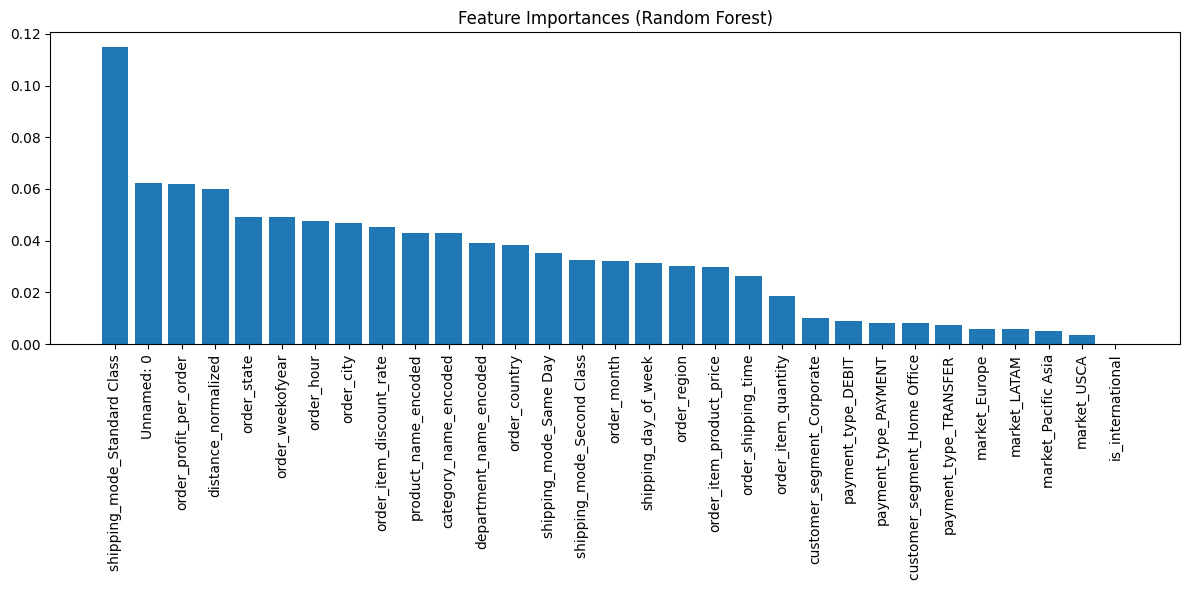

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = rf.feature_importances_
feature_names = X_train.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


In [8]:
pip install shap

   ---------------------------------------- 0.0/544.3 kB ? eta -:--:--
   ---------------------------------------- 544.3/544.3 kB 4.6 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ----------------

In [9]:
import shap
import pandas as pd

c:\Users\VP678WV\OneDrive - EY\Documents\Delivery_Delay\logistic_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Optional: ensure column names are preserved
X_test_df = pd.DataFrame(X_test, columns=feature_names)  # replace with your real feature names

In [11]:
explainer = shap.TreeExplainer(rf)

In [12]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[[-0.00201157, -0.0097751 ,  0.01178668],
        [ 0.00077839, -0.00518506,  0.00440667],
        [ 0.00116579, -0.00734919,  0.0061834 ],
        ...,
        [ 0.00065348, -0.01366144,  0.01300795],
        [ 0.00139421,  0.0008357 , -0.00222991],
        [-0.00154008, -0.00457315,  0.00611323]],

       [[ 0.00045022, -0.01215542,  0.0117052 ],
        [-0.00265603, -0.00409547,  0.0067515 ],
        [-0.00261633, -0.00588604,  0.00850237],
        ...,
        [-0.00326069, -0.00012267,  0.00338336],
        [-0.00325962, -0.00769649,  0.01095611],
        [-0.00178816, -0.00589253,  0.00768069]],

       [[-0.00086872, -0.02532659,  0.02619531],
        [-0.00264631, -0.0192723 ,  0.02191861],
        [-0.01001245, -0.00129278,  0.01130523],
        ...,
        [-0.0051836 , -0.00266457,  0.00784818],
        [-0.00498509,  0.00042885,  0.00455623],
        [-0.00339605, -0.01045592,  0.01385197]],

       ...,

       [[ 0.00360214, -0.0106481 ,  0.00704596],
        [-0

In [13]:
shap_values.shape

(2746, 36, 3)

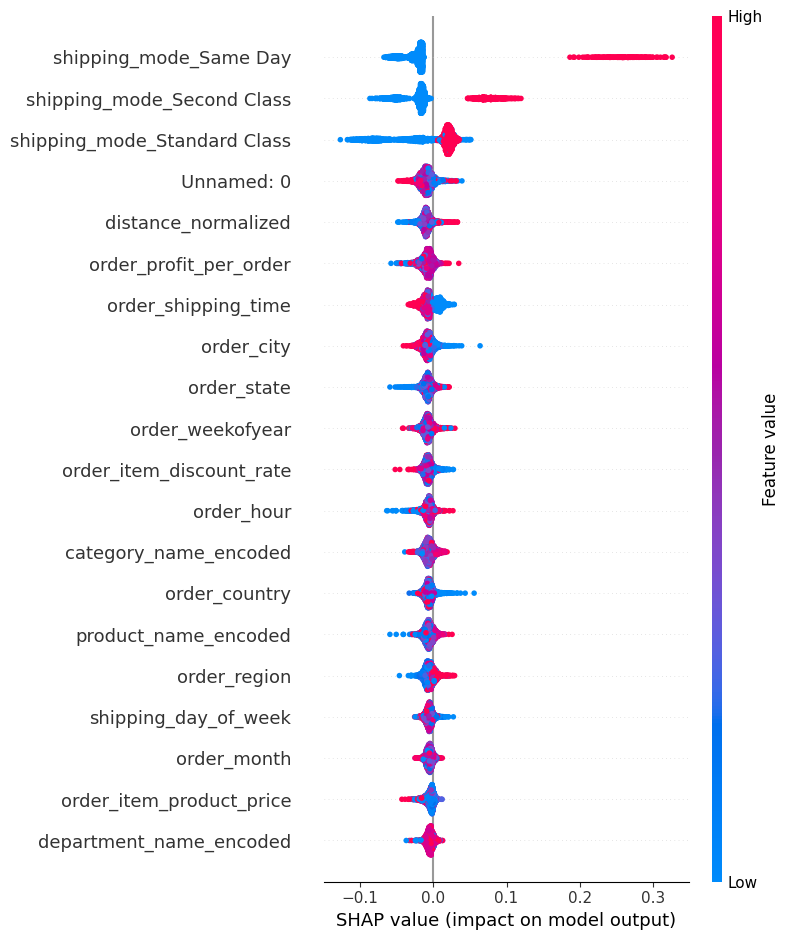

In [15]:
# Plot SHAP summary for class 1 (positive class)
shap.summary_plot(shap_values[:, :, 1], X_test_df)

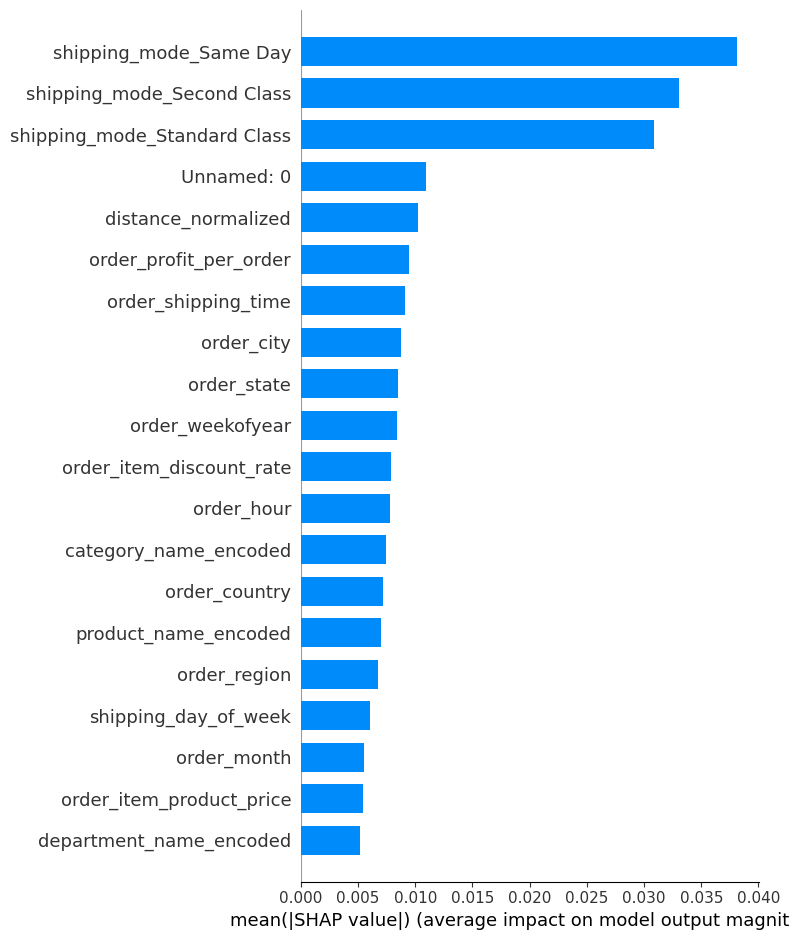

In [17]:
shap.summary_plot(shap_values[:, :, 1], X_test_df, plot_type="bar")

In [18]:
# Explain first test sample
i = 0
shap.force_plot(explainer.expected_value[1], shap_values[:, :, 1][i], X_test_df.iloc[i], feature_names=X_test_df.columns)